# Kaggle Notebook Link: https://www.kaggle.com/code/mennaabdelbaky/cnn-ipynb

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda


In [5]:
DATASET_PATH = "/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset"

## Explore Dataset

In [6]:
print("Dataset path:", DATASET_PATH)

classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Classes:")
for i, cls in enumerate(classes):
    print(i, "->", cls)

print("\nNumber of classes:", len(classes))

Dataset path: /kaggle/input/datasets/jehanbhathena/weather-dataset/dataset
Classes:
0 -> dew
1 -> fogsmog
2 -> frost
3 -> glaze
4 -> hail
5 -> lightning
6 -> rain
7 -> rainbow
8 -> rime
9 -> sandstorm
10 -> snow

Number of classes: 11


In [7]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    count = sum(
        1 for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count

class_counts

{'dew': 698,
 'fogsmog': 851,
 'frost': 475,
 'glaze': 639,
 'hail': 591,
 'lightning': 377,
 'rain': 526,
 'rainbow': 232,
 'rime': 1160,
 'sandstorm': 692,
 'snow': 621}

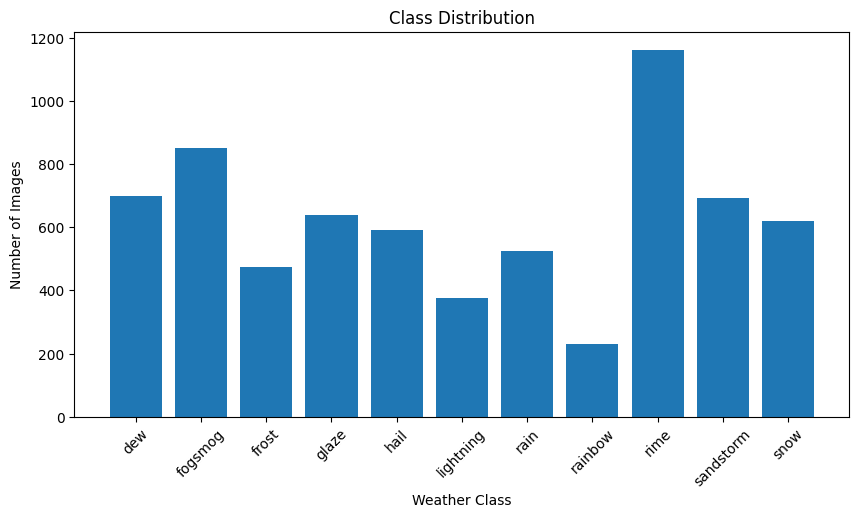

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xlabel("Weather Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)

plt.show()

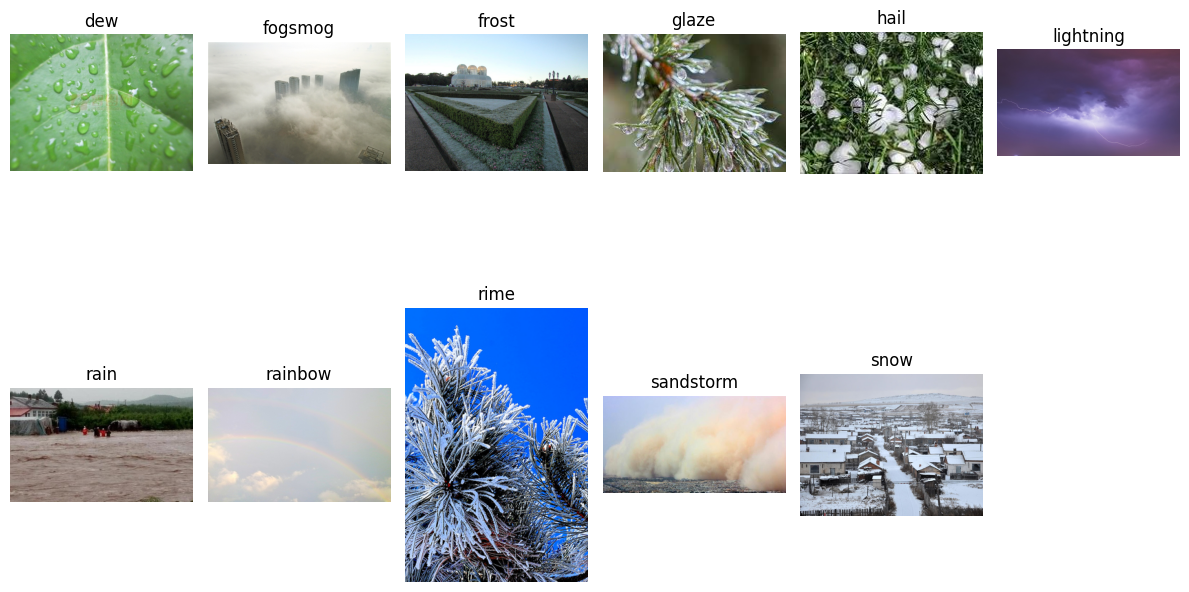

In [9]:
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    
    class_path = os.path.join(DATASET_PATH, cls)
    
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]
    
    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(2, (len(classes) + 1) // 2, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
image_sizes = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]
    
    for image_name in images[:100]:
        image_path = os.path.join(class_path, image_name)
        
        with Image.open(image_path) as img:
            image_sizes.append(img.size)

print("Number of inspected images:", len(image_sizes))
print("First 10 image sizes:", image_sizes[:10])

Number of inspected images: 1100
First 10 image sizes: [(400, 300), (400, 300), (400, 265), (1024, 662), (900, 600), (1280, 851), (400, 304), (500, 411), (400, 383), (1024, 964)]


## Data Splitting

In [11]:
from torch.utils.data import random_split

SEED = 42

torch.manual_seed(SEED)

full_dataset = datasets.ImageFolder(
    root=DATASET_PATH
)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class mapping:", full_dataset.class_to_idx)

Total images: 6862
Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
Class mapping: {'dew': 0, 'fogsmog': 1, 'frost': 2, 'glaze': 3, 'hail': 4, 'lightning': 5, 'rain': 6, 'rainbow': 7, 'rime': 8, 'sandstorm': 9, 'snow': 10}


In [12]:
total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4803
Validation: 1029
Test: 1030


## Image Preprocessing

In [13]:
IMG_SIZE = 180

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 151
Validation batches: 33
Test batches: 33


In [17]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 180, 180])
Labels shape: torch.Size([32])


## Augmentation

In [18]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    image = image * std + mean
    
    return torch.clamp(image, 0, 1)

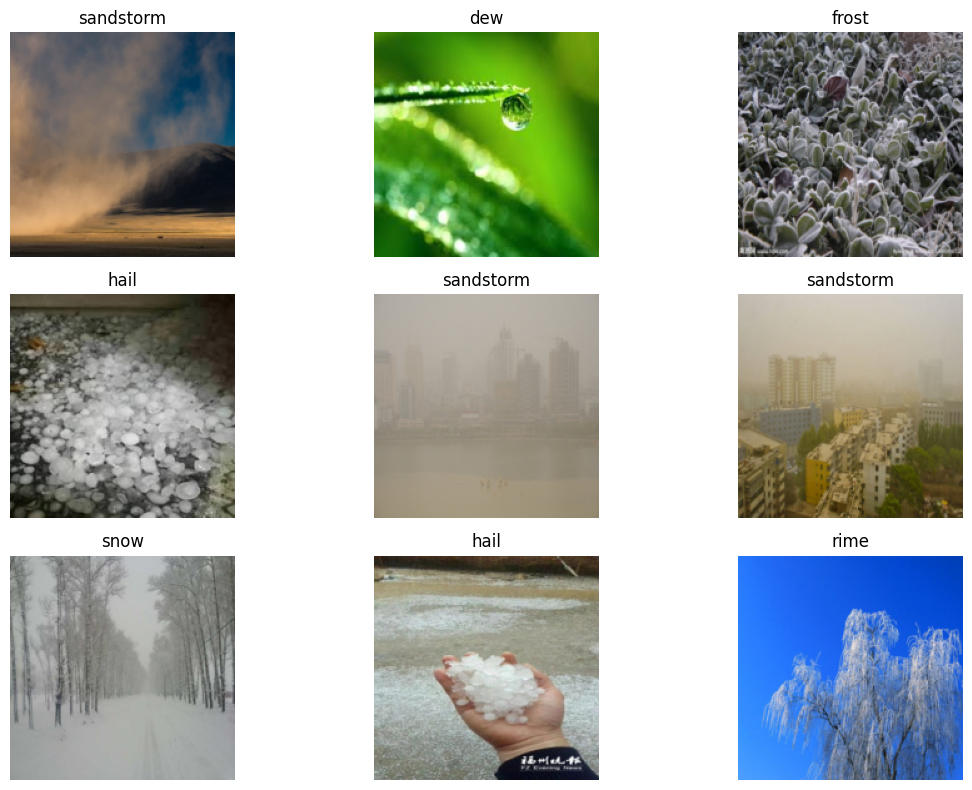

In [20]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):
    
    image = denormalize(images[i]).permute(1, 2, 0)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Basic CNN

In [21]:
class WeatherCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            
            nn.Flatten(),
            
            nn.Linear(64 * 22 * 22, 128),
            nn.ReLU(),
            
            nn.Dropout(0.2),
            
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        
        return x

In [22]:
NUM_CLASSES = len(classes)

model = WeatherCNN(NUM_CLASSES)

model = model.to(device)

print(model)

WeatherCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=30976, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=11, bias=True)
  )
)


In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [25]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [26]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [27]:
EPOCHS = 15

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/15] Train Loss: 1.4552 Train Acc: 0.5128 Val Loss: 1.1241 Val Acc: 0.6200
Epoch [2/15] Train Loss: 1.0311 Train Acc: 0.6567 Val Loss: 0.9170 Val Acc: 0.7046
Epoch [3/15] Train Loss: 0.8371 Train Acc: 0.7146 Val Loss: 0.9348 Val Acc: 0.6958
Epoch [4/15] Train Loss: 0.6042 Train Acc: 0.7966 Val Loss: 0.9802 Val Acc: 0.7153
Epoch [5/15] Train Loss: 0.4136 Train Acc: 0.8688 Val Loss: 1.0492 Val Acc: 0.6997
Epoch [6/15] Train Loss: 0.2637 Train Acc: 0.9136 Val Loss: 1.1860 Val Acc: 0.7366
Epoch [7/15] Train Loss: 0.1726 Train Acc: 0.9448 Val Loss: 1.4805 Val Acc: 0.7201
Epoch [8/15] Train Loss: 0.1436 Train Acc: 0.9507 Val Loss: 1.7620 Val Acc: 0.7143
Epoch [9/15] Train Loss: 0.0969 Train Acc: 0.9706 Val Loss: 1.5535 Val Acc: 0.7123
Epoch [10/15] Train Loss: 0.0867 Train Acc: 0.9704 Val Loss: 1.6502 Val Acc: 0.7172
Epoch [11/15] Train Loss: 0.0830 Train Acc: 0.9758 Val Loss: 1.8677 Val Acc: 0.6939
Epoch [12/15] Train Loss: 0.0891 Train Acc: 0.9706 Val Loss: 1.9023 Val Acc: 0.7007
E

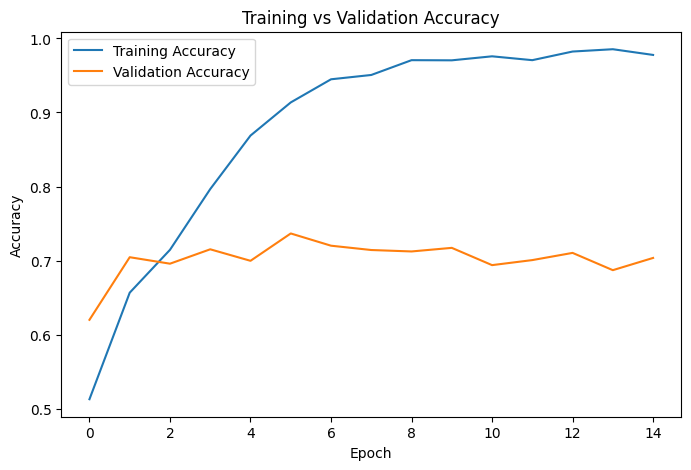

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

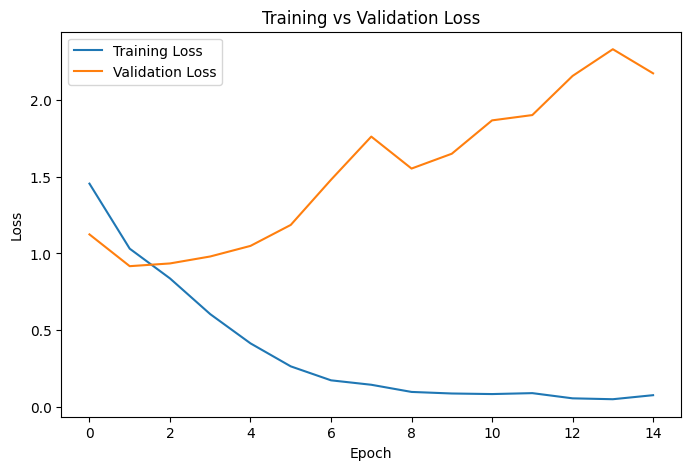

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [30]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [31]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7078


In [32]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    )
)

              precision    recall  f1-score   support

         dew       0.86      0.84      0.85       120
     fogsmog       0.81      0.79      0.80       116
       frost       0.51      0.52      0.52        77
       glaze       0.56      0.65      0.60        80
        hail       0.71      0.61      0.66       100
   lightning       0.71      0.95      0.81        59
        rain       0.59      0.48      0.53        85
     rainbow       0.88      0.43      0.58        35
        rime       0.76      0.81      0.78       159
   sandstorm       0.80      0.86      0.83       109
        snow       0.54      0.53      0.54        90

    accuracy                           0.71      1030
   macro avg       0.70      0.68      0.68      1030
weighted avg       0.71      0.71      0.70      1030



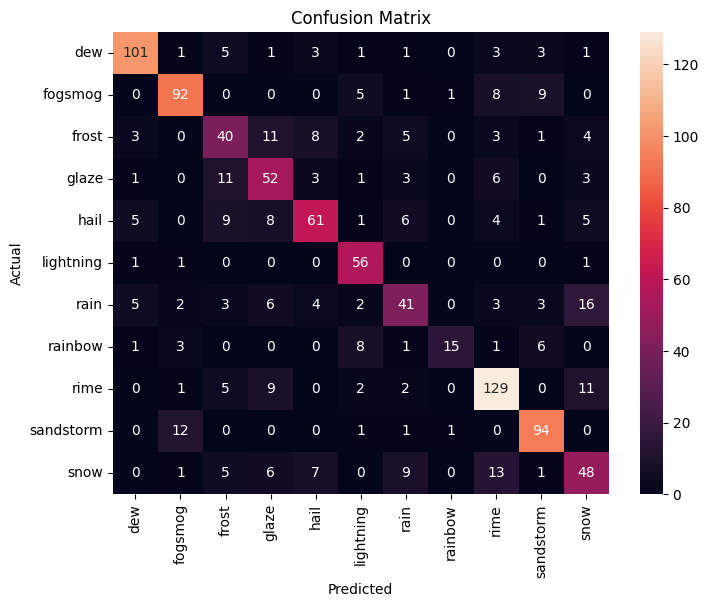

In [33]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [34]:
model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    outputs = model(images_device)

    _, predictions = torch.max(outputs, 1)

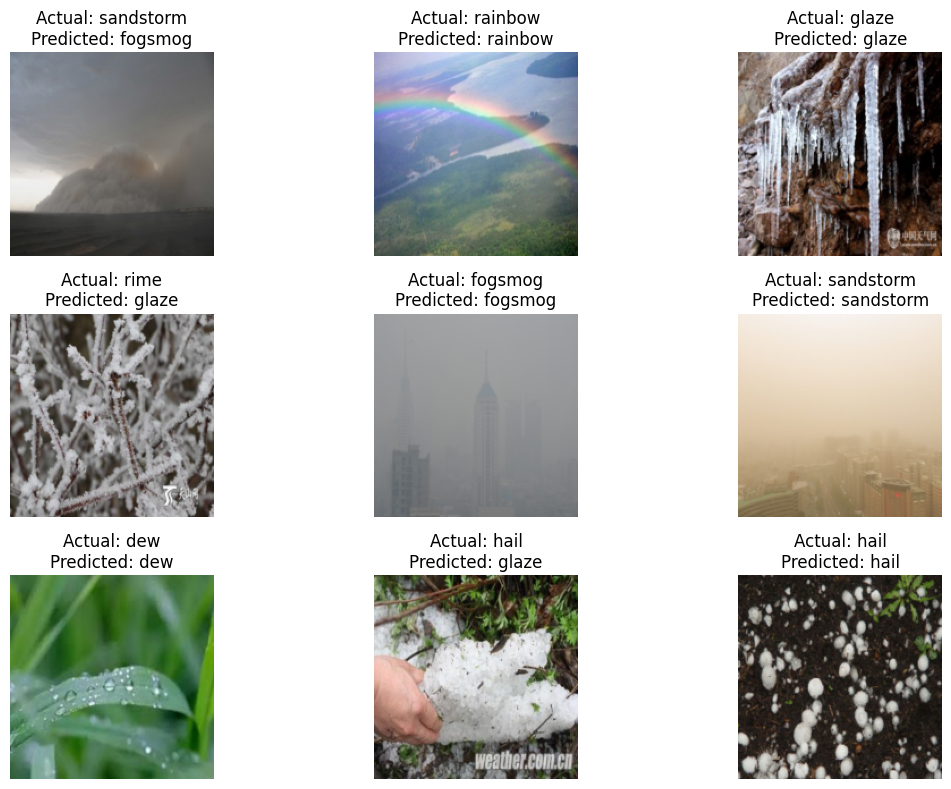

In [35]:
plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):

    image = denormalize(images[i]).permute(1, 2, 0)

    actual = classes[labels[i]]
    predicted = classes[predictions[i].cpu()]

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Transfer Learning

In [36]:
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights

In [37]:
weights = EfficientNet_B1_Weights.DEFAULT

model_2 = efficientnet_b1(weights=weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 219MB/s]


In [39]:
for param in model_2.parameters():
    param.requires_grad = False

In [41]:
num_features = model_2.classifier[1].in_features

model_2.classifier[1] = nn.Linear(
    num_features,
    NUM_CLASSES
)

In [43]:
model_2 = model_2.to(device)

In [45]:
criterion_2 = nn.CrossEntropyLoss()

optimizer_2 = optim.Adam(
    model_2.classifier.parameters(),
    lr=0.001
)

In [46]:
EPOCHS_2 = 10

train_losses_2 = []
train_accuracies_2 = []

val_losses_2 = []
val_accuracies_2 = []

for epoch in range(EPOCHS_2):

    train_loss, train_acc = train_one_epoch(
        model_2,
        train_loader,
        criterion_2,
        optimizer_2
    )

    val_loss, val_acc = validate(
        model_2,
        val_loader,
        criterion_2
    )

    train_losses_2.append(train_loss)
    train_accuracies_2.append(train_acc)

    val_losses_2.append(val_loss)
    val_accuracies_2.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS_2}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] Train Loss: 1.4613 Train Acc: 0.6960 Val Loss: 0.9692 Val Acc: 0.8124
Epoch [2/10] Train Loss: 0.7940 Train Acc: 0.8132 Val Loss: 0.7136 Val Acc: 0.8319
Epoch [3/10] Train Loss: 0.6285 Train Acc: 0.8374 Val Loss: 0.6002 Val Acc: 0.8523
Epoch [4/10] Train Loss: 0.5576 Train Acc: 0.8457 Val Loss: 0.5554 Val Acc: 0.8542
Epoch [5/10] Train Loss: 0.5070 Train Acc: 0.8516 Val Loss: 0.5126 Val Acc: 0.8523
Epoch [6/10] Train Loss: 0.4688 Train Acc: 0.8622 Val Loss: 0.4929 Val Acc: 0.8669
Epoch [7/10] Train Loss: 0.4532 Train Acc: 0.8657 Val Loss: 0.4817 Val Acc: 0.8639
Epoch [8/10] Train Loss: 0.4260 Train Acc: 0.8711 Val Loss: 0.4723 Val Acc: 0.8591
Epoch [9/10] Train Loss: 0.4232 Train Acc: 0.8753 Val Loss: 0.4678 Val Acc: 0.8659
Epoch [10/10] Train Loss: 0.3998 Train Acc: 0.8745 Val Loss: 0.4503 Val Acc: 0.8571


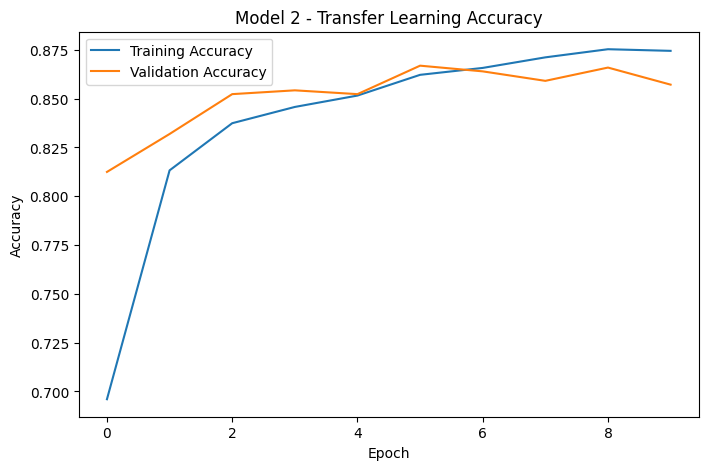

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies_2,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies_2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 2 - Transfer Learning Accuracy")

plt.legend()
plt.show()

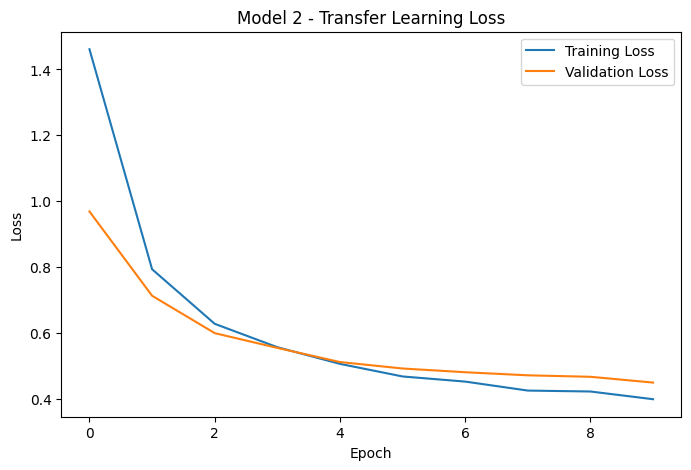

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_2,
    label="Training Loss"
)

plt.plot(
    val_losses_2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 - Transfer Learning Loss")

plt.legend()
plt.show()

In [50]:
model_2.eval()

predictions_2 = []
labels_2 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_2(images)

        _, predicted = torch.max(outputs, 1)

        predictions_2.extend(
            predicted.cpu().numpy()
        )

        labels_2.extend(
            labels.numpy()
        )

In [51]:
accuracy_2 = accuracy_score(
    labels_2,
    predictions_2
)

print(f"Model 2 Test Accuracy: {accuracy_2:.4f}")

Model 2 Test Accuracy: 0.8854


In [52]:
print(
    classification_report(
        labels_2,
        predictions_2,
        target_names=classes
    )
)

              precision    recall  f1-score   support

         dew       0.97      0.96      0.96       120
     fogsmog       0.84      0.92      0.88       116
       frost       0.86      0.81      0.83        77
       glaze       0.76      0.80      0.78        80
        hail       0.95      0.92      0.93       100
   lightning       0.97      0.97      0.97        59
        rain       0.85      0.81      0.83        85
     rainbow       1.00      0.97      0.99        35
        rime       0.89      0.92      0.91       159
   sandstorm       0.90      0.90      0.90       109
        snow       0.82      0.74      0.78        90

    accuracy                           0.89      1030
   macro avg       0.89      0.88      0.89      1030
weighted avg       0.89      0.89      0.89      1030



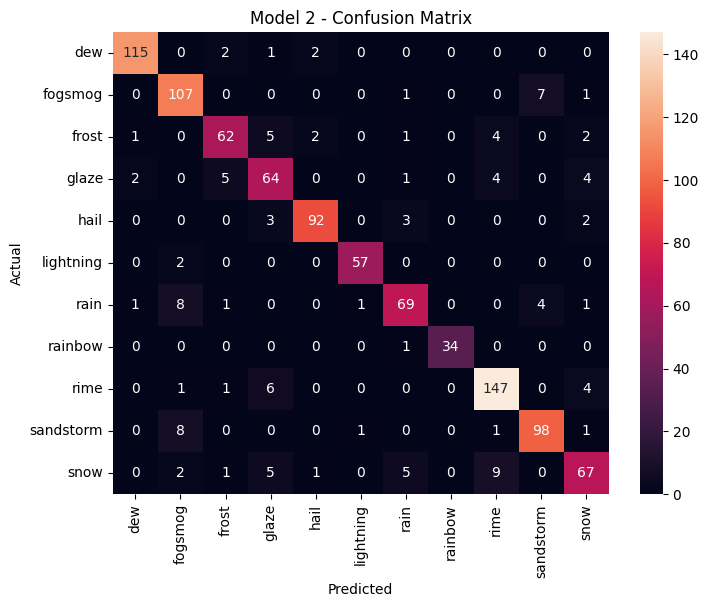

In [53]:
cm_2 = confusion_matrix(
    labels_2,
    predictions_2
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_2,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 2 - Confusion Matrix")

plt.show()

# Tranfer Learning + Fine Tuning

In [55]:
import copy

model_3 = copy.deepcopy(model_2)
model_3 = model_3.to(device)

In [56]:
for param in model_3.parameters():
    param.requires_grad = False

In [59]:
for param in model_3.features[7].parameters():
    param.requires_grad = True

for param in model_3.classifier.parameters():
    param.requires_grad = True

In [60]:
total_params = 0
trainable_params = 0

for param in model_3.parameters():

    total_params += param.numel()

    if param.requires_grad:
        trainable_params += param.numel()

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)

Total parameters: 6,527,275
Trainable parameters: 2,294,923
Trainable percentage: 35.16%


In [61]:
criterion_3 = nn.CrossEntropyLoss()
optimizer_3 = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_3.parameters()
    ),
    lr=1e-5
)


In [62]:
EPOCHS_3 = 10

train_losses_3 = []
train_accuracies_3 = []

val_losses_3 = []
val_accuracies_3 = []

for epoch in range(EPOCHS_3):

    train_loss, train_acc = train_one_epoch(
        model_3,
        train_loader,
        criterion_3,
        optimizer_3
    )

    val_loss, val_acc = validate(
        model_3,
        val_loader,
        criterion_3
    )

    train_losses_3.append(train_loss)
    train_accuracies_3.append(train_acc)

    val_losses_3.append(val_loss)
    val_accuracies_3.append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS_3}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] | Train Loss: 0.3812 | Train Acc: 0.8828 | Val Loss: 0.4398 | Val Acc: 0.8630
Epoch [2/10] | Train Loss: 0.3754 | Train Acc: 0.8776 | Val Loss: 0.4201 | Val Acc: 0.8717
Epoch [3/10] | Train Loss: 0.3518 | Train Acc: 0.8857 | Val Loss: 0.4173 | Val Acc: 0.8717
Epoch [4/10] | Train Loss: 0.3396 | Train Acc: 0.8924 | Val Loss: 0.4071 | Val Acc: 0.8737
Epoch [5/10] | Train Loss: 0.3432 | Train Acc: 0.8909 | Val Loss: 0.4052 | Val Acc: 0.8717
Epoch [6/10] | Train Loss: 0.3648 | Train Acc: 0.8828 | Val Loss: 0.4132 | Val Acc: 0.8756
Epoch [7/10] | Train Loss: 0.3215 | Train Acc: 0.8974 | Val Loss: 0.4062 | Val Acc: 0.8678
Epoch [8/10] | Train Loss: 0.3173 | Train Acc: 0.9005 | Val Loss: 0.3966 | Val Acc: 0.8737
Epoch [9/10] | Train Loss: 0.3068 | Train Acc: 0.8996 | Val Loss: 0.4047 | Val Acc: 0.8766
Epoch [10/10] | Train Loss: 0.3166 | Train Acc: 0.8996 | Val Loss: 0.3881 | Val Acc: 0.8776


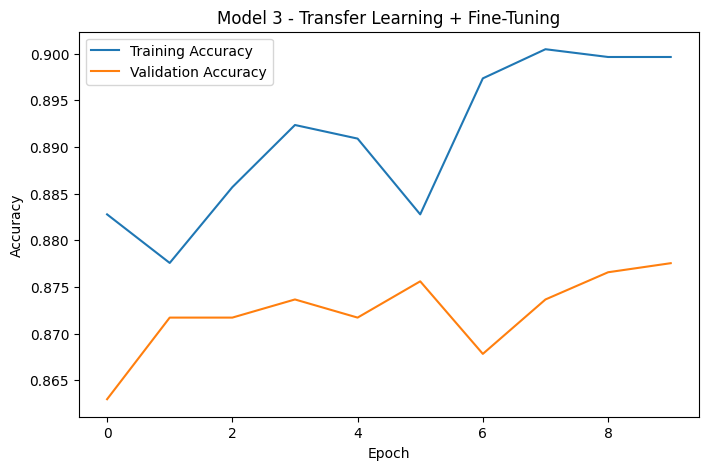

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies_3,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies_3,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 3 - Transfer Learning + Fine-Tuning")

plt.legend()
plt.show()

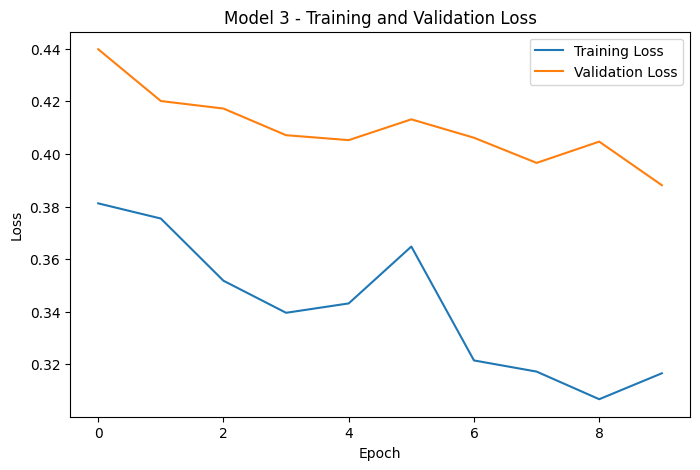

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_3,
    label="Training Loss"
)

plt.plot(
    val_losses_3,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 - Training and Validation Loss")

plt.legend()
plt.show()

In [65]:
model_3.eval()

predictions_3 = []
labels_3 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_3(images)

        _, predicted = torch.max(outputs, 1)

        predictions_3.extend(
            predicted.cpu().numpy()
        )

        labels_3.extend(
            labels.numpy()
        )

In [66]:
accuracy_3 = accuracy_score(
    labels_3,
    predictions_3
)

print(f"Model 3 Test Accuracy: {accuracy_3:.4f}")

Model 3 Test Accuracy: 0.8922


In [67]:
print(
    classification_report(
        labels_3,
        predictions_3,
        target_names=classes
    )
)

              precision    recall  f1-score   support

         dew       0.97      0.96      0.97       120
     fogsmog       0.86      0.94      0.90       116
       frost       0.82      0.84      0.83        77
       glaze       0.75      0.80      0.78        80
        hail       0.96      0.92      0.94       100
   lightning       0.98      0.98      0.98        59
        rain       0.85      0.85      0.85        85
     rainbow       1.00      0.97      0.99        35
        rime       0.89      0.92      0.90       159
   sandstorm       0.91      0.90      0.90       109
        snow       0.88      0.73      0.80        90

    accuracy                           0.89      1030
   macro avg       0.90      0.89      0.89      1030
weighted avg       0.89      0.89      0.89      1030



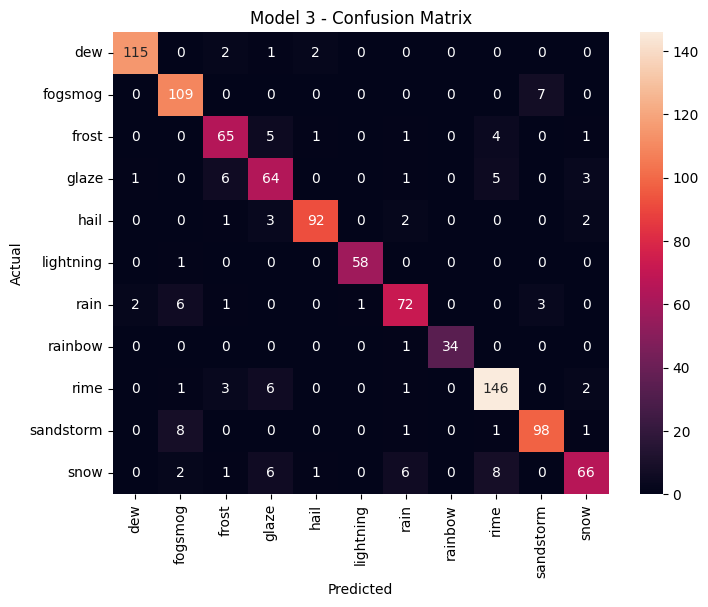

In [68]:
cm_3 = confusion_matrix(
    labels_3,
    predictions_3
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_3,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 3 - Confusion Matrix")

plt.show()

## Compare Bsic CNN vs Transfer Learning vs Transfer Learning + Fine Tuning

In [70]:
results = pd.DataFrame({
    "Model": [
        "Model",
        "Model 2",
        "Model 3"
    ],
    "Test Accuracy": [
        test_accuracy,
        accuracy_2,
        accuracy_3
    ]
})

results

,Model,Test Accuracy
0,Model,0.707767
1,Model 2,0.885437
2,Model 3,0.892233
